# Validation reward curves

This notebook reads TensorBoard logs and plots validation reward over training episodes for selected runs.

In [1]:
from pathlib import Path

import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


REPO_FALLBACK = Path("/Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team")

try:
    NOTEBOOK_DIR = Path.cwd().resolve()
except FileNotFoundError:
    # This can happen when a Jupyter kernel keeps a deleted or moved cwd.
    NOTEBOOK_DIR = REPO_FALLBACK / "statistic"
    os.chdir(REPO_FALLBACK)

PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "statistic" else NOTEBOOK_DIR
LOG_ROOT = PROJECT_ROOT / "logs2"
MLP_LOG_ROOT = PROJECT_ROOT / "logs"
CNN_LOG_ROOT = PROJECT_ROOT / "logs2"
TAG = "Reward/validation"


def read_scalar_series(run_path: Path, tag: str = TAG, max_step: int | None = None):
    if not run_path.exists():
        raise FileNotFoundError(f"Missing TensorBoard log directory: {run_path}")

    event_files = list(run_path.glob("events.out.tfevents*"))
    if not event_files:
        raise FileNotFoundError(f"No TensorBoard event file found in: {run_path}")

    accumulator = EventAccumulator(str(run_path), size_guidance={"scalars": 0})
    accumulator.Reload()

    scalar_tags = accumulator.Tags().get("scalars", [])
    if tag not in scalar_tags:
        raise KeyError(f"Tag {tag!r} not found in {run_path}. Available scalar tags: {scalar_tags}")

    series = [(point.step, point.value) for point in accumulator.Scalars(tag)]
    if max_step is not None:
        series = [(step, value) for step, value in series if step <= max_step]

    if not series:
        raise ValueError(f"No scalar points left after filtering {tag!r} to step <= {max_step}")

    return series


def load_curves(runs, tag: str = TAG, total_episodes: int | None = None):
    curves = []
    missing_runs = []

    for run in runs:
        try:
            series = read_scalar_series(run["path"], tag=tag, max_step=total_episodes)
        except Exception as exc:
            missing_runs.append((run["name"], run["path"], exc))
            continue

        best_step, best_value = max(series, key=lambda item: item[1])
        curves.append({**run, "series": series, "best_step": best_step, "best_value": best_value})

    return curves, missing_runs


def print_curve_summary(curves, missing_runs):
    for curve in curves:
        print(
            f"{curve['name']}: {len(curve['series'])} points, "
            f"best validation reward = {curve['best_value']:.3f} at episode {curve['best_step']}"
        )

    if missing_runs:
        print("\nRuns not plotted:")
        for name, path, exc in missing_runs:
            print(f"- {name}: {path} ({exc})")


def plot_validation_curves(
    curves,
    variant: int,
    total_episodes: int,
    axis_width: float = 8.0,
    right_panel_width: float = 5.0,
    left_margin_width: float = 1.25,
    panel_gap_width: float = 0.25,
    height: float = 5.6,
    y_min: float = 0,
    compressed_y_threshold: float | None = None,
    policy_name: str = "Rainbow DQN",
    x_tick_interval: int = 3000,
    feature_engineering_approach: str | None = None,
    best_reward_x: float = 0.36,
):
    if not curves:
        raise RuntimeError("No curves were loaded. Check RUNS and LOG_ROOT above.")

    fig_width = left_margin_width + axis_width + panel_gap_width + right_panel_width
    fig = plt.figure(figsize=(fig_width, height), dpi=140)

    bottom_margin = 0.72
    top_margin = 0.22
    plot_height = height - bottom_margin - top_margin

    ax = fig.add_axes([
        left_margin_width / fig_width,
        bottom_margin / height,
        axis_width / fig_width,
        plot_height / height,
    ])
    legend_ax = fig.add_axes([
        (left_margin_width + axis_width + panel_gap_width) / fig_width,
        bottom_margin / height,
        right_panel_width / fig_width,
        plot_height / height,
    ])
    legend_ax.axis("off")

    for curve in curves:
        steps = [step for step, _ in curve["series"]]
        rewards = [value for _, value in curve["series"]]
        ax.plot(steps, rewards, label=curve["name"], color=curve["color"], linewidth=2.2)

    legend_x = 0.03
    legend_y = 0.98
    line_width = 0.09
    text_gap = 0.035
    line_gap = 0.070
    row_gap = 0.055
    legend_width = 0.88

    row_heights = [line_gap * max(1, len(curve["name"].splitlines())) for curve in curves]
    legend_height = sum(row_heights) + row_gap * (len(curves) - 1) + 0.055
    legend_box = FancyBboxPatch(
        (0.0, legend_y - legend_height + 0.02),
        legend_width,
        legend_height,
        boxstyle="round,pad=0.012",
        facecolor="white",
        edgecolor="0.8",
        transform=legend_ax.transAxes,
        clip_on=False,
        zorder=10,
    )
    legend_ax.add_patch(legend_box)

    current_y = legend_y - 0.035
    for curve in curves:
        label_lines = curve["name"].splitlines()
        first_line = label_lines[0]
        best_reward_prefix = "Best Validation Reward:"
        if best_reward_prefix in first_line:
            legend_label, best_reward = first_line.split(best_reward_prefix, maxsplit=1)
            legend_label = legend_label.rstrip()
            best_reward_label = f"{best_reward_prefix}{best_reward}"
        else:
            legend_label = first_line
            best_reward_label = None
        legend_ax.plot(
            [legend_x, legend_x + line_width],
            [current_y, current_y],
            transform=legend_ax.transAxes,
            color=curve["color"],
            linewidth=2.8,
            clip_on=False,
            zorder=11,
        )
        legend_ax.text(
            legend_x + line_width + text_gap,
            current_y,
            legend_label,
            transform=legend_ax.transAxes,
            ha="left",
            va="center",
            fontsize=10,
            zorder=11,
        )
        if best_reward_label is not None:
            legend_ax.text(
                best_reward_x,
                current_y,
                best_reward_label,
                transform=legend_ax.transAxes,
                ha="left",
                va="center",
                fontsize=10,
                zorder=11,
            )
        for line_idx, label_line in enumerate(label_lines[1:], start=1):
            legend_ax.text(
                legend_x + line_width + text_gap,
                current_y - line_gap * line_idx,
                label_line,
                transform=legend_ax.transAxes,
                ha="left",
                va="center",
                fontsize=10,
                zorder=11,
            )
        current_y -= line_gap * max(1, len(label_lines)) + row_gap

    info_y = legend_y - legend_height - 0.045
    info_lines = [
        f"Variant: {variant}",
        f"Total Episodes: {total_episodes // 1000}k",
        f"DRL Policy: {policy_name}",
    ]
    if feature_engineering_approach is not None:
        info_lines.append(f"Feature Engineering Approach: {feature_engineering_approach}")
    for line_idx, info_line in enumerate(info_lines):
        legend_ax.text(
            legend_x,
            info_y - 0.085 * line_idx,
            info_line,
            transform=legend_ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
        )

    ax.set_xlabel("Training Episode", labelpad=10)
    ax.set_ylabel("Average Validation Reward", labelpad=12)
    ax.set_xlim(0, total_episodes)
    if compressed_y_threshold is None:
        ax.set_ylim(bottom=y_min)
    else:
        # Compress 0..threshold into the height of one regular 10-reward grid cell.
        threshold = float(compressed_y_threshold)
        compressed_height = 10.0

        def compress_y(values):
            values = np.asarray(values)
            return np.where(
                values <= threshold,
                values * compressed_height / threshold,
                compressed_height + values - threshold,
            )

        def restore_y(values):
            values = np.asarray(values)
            return np.where(
                values <= compressed_height,
                values * threshold / compressed_height,
                threshold + values - compressed_height,
            )

        reward_max = max(value for curve in curves for _, value in curve["series"])
        y_top = np.ceil((reward_max + 4) / 10) * 10
        ax.set_yscale("function", functions=(compress_y, restore_y))
        ax.set_ylim(0, y_top)
        ax.set_yticks(np.concatenate(([0], np.arange(threshold, y_top + 1, 10))))

        # Mark the compressed interval on the y-axis.
        fig.canvas.draw()
        break_y = ax.transAxes.inverted().transform(
            ax.transData.transform((0, threshold / 2))
        )[1]
        marker_kwargs = dict(
            transform=ax.transAxes, color="black", clip_on=False, linewidth=1.0
        )
        ax.plot((-0.009, 0.009), (break_y - 0.010, break_y + 0.010), **marker_kwargs)
        ax.plot((-0.009, 0.009), (break_y + 0.008, break_y + 0.028), **marker_kwargs)
    ax.set_xticks(range(0, total_episodes + 1, x_tick_interval))
    ax.grid(axis="x", linestyle="--", alpha=0.28)
    ax.grid(axis="y", linestyle="-", alpha=0.18)

    return fig, ax


print(f"Project root: {PROJECT_ROOT}")
print(f"Log root: {LOG_ROOT}")


Project root: /Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team
Log root: /Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team/logs2


2026-07-19 17:17:14.127206: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Training Results with Item Value Channel
Best Validation Reward: 226.13: 300 points, best validation reward = 226.130 at episode 21000
Training Results with Item Value Channel(Simple Version)
Best Validation Reward: 225.55: 100 points, best validation reward = 221.545 at episode 7200
Training Results without Item Value Channel
Best Validation Reward: 225.48: 300 points, best validation reward = 225.480 at episode 23900


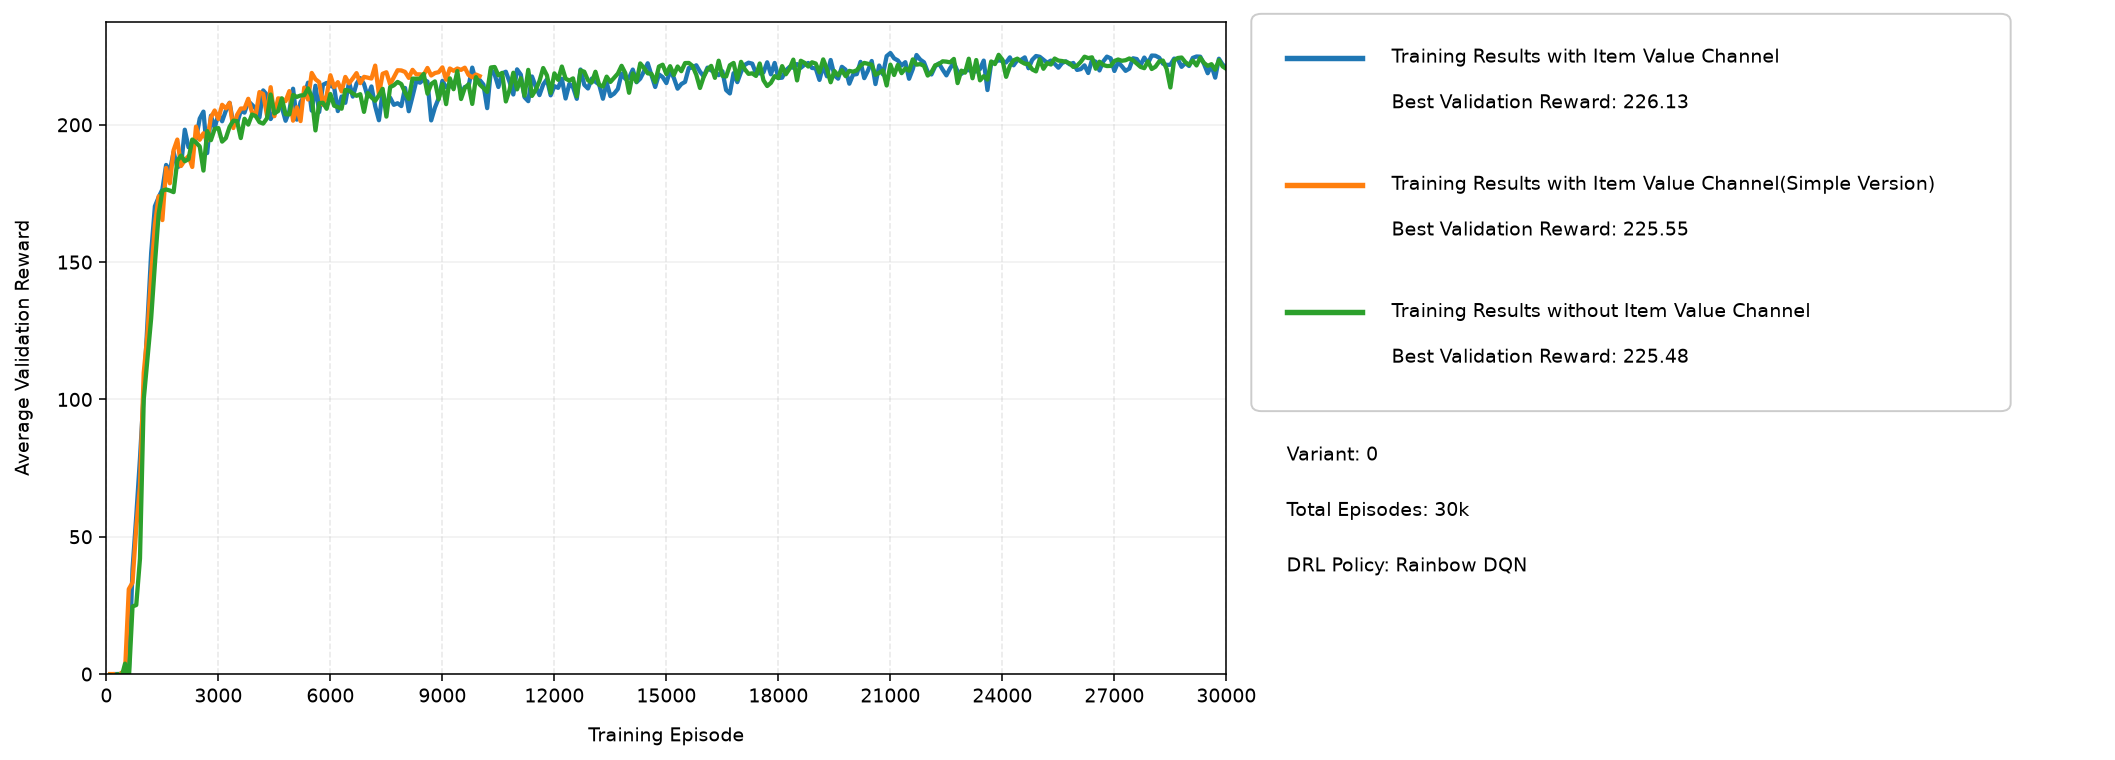

In [2]:
VARIANT = 0
TOTAL_EPISODES = 30_000

RUNS = [
    {
        "name": "Training Results with Item Value Channel\nBest Validation Reward: 226.13",
        "path": LOG_ROOT / "DQN_v8.11.10_variant_0",
        "color": "tab:blue",
    },
    {
        "name": "Training Results with Item Value Channel(Simple Version)\nBest Validation Reward: 225.55",
        "path": LOG_ROOT / "DQN_v8.12.0_variant_0",
        "color": "tab:orange",
    },
    {
        "name": "Training Results without Item Value Channel\nBest Validation Reward: 225.48",
        "path": LOG_ROOT / "DQN_v8.9.2_variant_0",
        "color": "tab:green",
    },
]

curves, missing_runs = load_curves(RUNS, total_episodes=TOTAL_EPISODES)
print_curve_summary(curves, missing_runs)
fig, ax = plot_validation_curves(
    curves,
    variant=VARIANT,
    total_episodes=TOTAL_EPISODES,
    axis_width=8.0,
    right_panel_width=6,
)
plt.show()

## Feature engineering comparison

Comparison of basic information, reachability, and reachability plus item value.

Only with Basic Information Best Validation Reward: 224.96: 300 points, best validation reward = 224.960 at episode 24500
With Reachability Best Validation Reward: 225.48: 300 points, best validation reward = 225.480 at episode 23900
With Reachability and Item Value Best Validation Reward: 226.13: 300 points, best validation reward = 226.130 at episode 21000


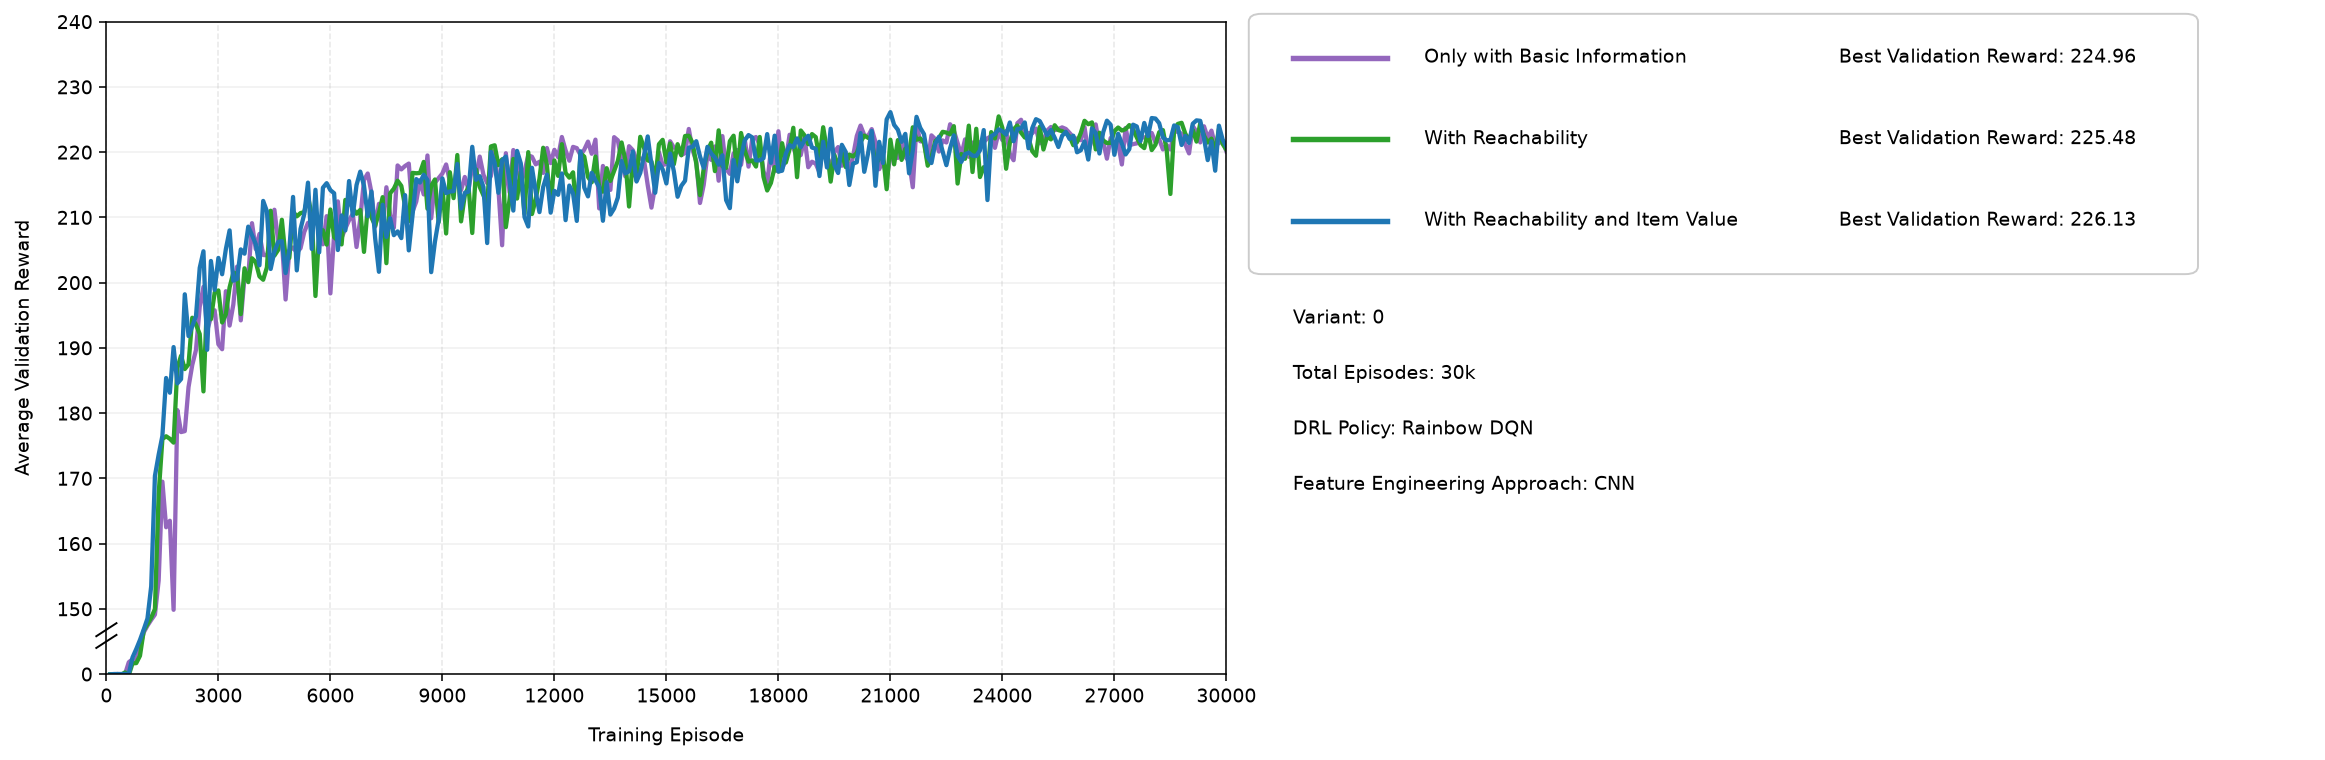

In [3]:
FEATURE_ENGINEERING_RUNS = [
    {
        "name": "Only with Basic Information Best Validation Reward: 224.96",
        "path": LOG_ROOT / "DQN_v8.5.28_variant_0",
        "color": "tab:purple",
    },
    {
        "name": "With Reachability Best Validation Reward: 225.48",
        "path": LOG_ROOT / "DQN_v8.9.2_variant_0",
        "color": "tab:green",
    },
    {
        "name": "With Reachability and Item Value Best Validation Reward: 226.13",
        "path": LOG_ROOT / "DQN_v8.11.10_variant_0",
        "color": "tab:blue",
    },
]

feature_engineering_curves, feature_engineering_missing_runs = load_curves(
    FEATURE_ENGINEERING_RUNS,
    total_episodes=30_000,
)
print_curve_summary(feature_engineering_curves, feature_engineering_missing_runs)
feature_engineering_fig, feature_engineering_ax = plot_validation_curves(
    feature_engineering_curves,
    variant=VARIANT,
    total_episodes=30_000,
    axis_width=8.0,
    right_panel_width=7.5,
    compressed_y_threshold=150,
    feature_engineering_approach="CNN",
    best_reward_x=0.55,
)
plt.show()

## MLP, CNN, and hybrid architecture comparison

Validation reward comparison for MLP1 v3.6, MLP2 v1.11, MLP3 v3.5, CNN v2.1, and hybrid v9.6.1 on variant 0. The MLP and hybrid runs are loaded from `logs/`; the CNN run is loaded from its actual repository location in `logs2/`.

MLP1 Best Validation Reward: 181.86: 100 points, best validation reward = 181.855 at episode 6300
MLP2 Best Validation Reward: 200.13: 100 points, best validation reward = 200.130 at episode 10000
MLP3 Best Validation Reward: 191.70: 100 points, best validation reward = 191.700 at episode 6000
CNN Best Validation Reward: 222.67: 100 points, best validation reward = 222.665 at episode 10000
Hybrid Best Validation Reward: 223.28: 100 points, best validation reward = 223.280 at episode 7800


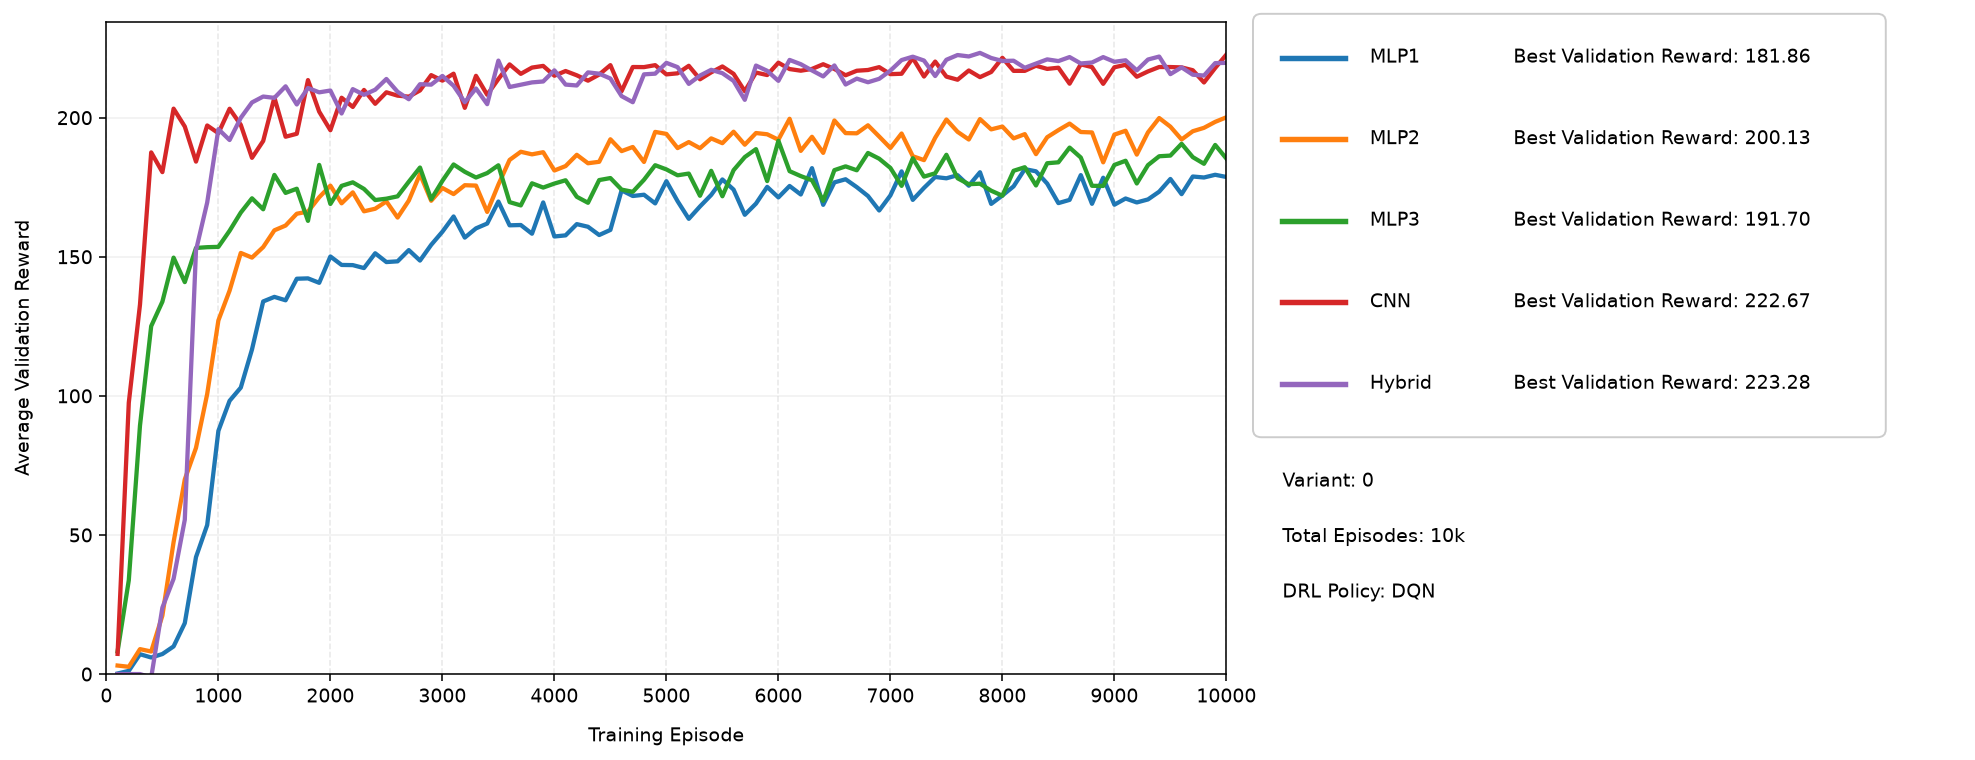

In [4]:
ARCHITECTURE_RUNS = [
    {
        "name": "MLP1 Best Validation Reward: 181.86",
        "path": MLP_LOG_ROOT / "DQN_v3.6_variant_0",
        "color": "tab:blue",
    },
    {
        "name": "MLP2 Best Validation Reward: 200.13",
        "path": MLP_LOG_ROOT / "DQN_v1.11_variant_0",
        "color": "tab:orange",
    },
    {
        "name": "MLP3 Best Validation Reward: 191.70",
        "path": MLP_LOG_ROOT / "DQN_v3.5_variant_0",
        "color": "tab:green",
    },
    {
        "name": "CNN Best Validation Reward: 222.67",
        "path": CNN_LOG_ROOT / "DQN_CNN_v2.1_variant_0",
        "color": "tab:red",
    },
    {
        "name": "Hybrid Best Validation Reward: 223.28",
        "path": MLP_LOG_ROOT / "DQN_v9.6.1_variant_0",
        "color": "tab:purple",
    },
]

ARCHITECTURE_TOTAL_EPISODES = 10_000
architecture_curves, architecture_missing_runs = load_curves(
    ARCHITECTURE_RUNS,
    total_episodes=ARCHITECTURE_TOTAL_EPISODES,
)
print_curve_summary(architecture_curves, architecture_missing_runs)
architecture_fig, architecture_ax = plot_validation_curves(
    architecture_curves,
    variant=0,
    total_episodes=ARCHITECTURE_TOTAL_EPISODES,
    axis_width=8.0,
    right_panel_width=5.0,
    policy_name="DQN",
    x_tick_interval=1000,
)
plt.show()